# Grounding con Qwen2.5-VL — instructions.md + conteo

Notebook independiente — carga sus propios datos (JSON del Stage 1 + imágenes de Drive) sin depender de otros notebooks.

Enfoque: instrucciones fijas (criterio de tono de piel, qué NO cuenta, formato de salida) + el conteo de figuras del Stage 1 como ancla numérica, en vez de la descripción física larga.

## 1. Instalar dependencias base

In [4]:
!pip install -q -U google-api-python-client


## 2. Subir los 3 JSON de prueba

Selecciona `3406.json`, `90001.json`, `90002.json`.

In [5]:
from google.colab import files

uploaded = files.upload()
print("Archivos subidos:", list(uploaded.keys()))


Saving 3406.json to 3406.json
Saving 11484.json to 11484.json
Saving 90001.json to 90001.json
Saving 90002.json to 90002.json
Archivos subidos: ['3406.json', '11484.json', '90001.json', '90002.json']


## 3. Funciones de carga (Drive + Stage 1)

In [6]:
import io
import json
import glob
from pathlib import Path
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

CORPUS_FOLDER_ID = "1yw28_N0MEnXQKD89DZVl_usjNk1rY_cU"
IMAGE_CACHE_DIR = "cache_images"


def get_drive_service():
    """Autenticacion para Colab (pide consentimiento una vez por sesion)."""
    from google.colab import auth
    auth.authenticate_user()
    return build("drive", "v3")


def find_drive_file_by_id(drive_service, image_id: str, folder_id: str = CORPUS_FOLDER_ID):
    """Busca en la carpeta corpus un archivo cuyo nombre base sea exactamente image_id."""
    query = f"'{folder_id}' in parents and name contains '{image_id}' and trashed = false"
    response = drive_service.files().list(q=query, fields="files(id, name, mimeType)").execute()
    candidates = response.get("files", [])
    exact_matches = [f for f in candidates if Path(f["name"]).stem == image_id]
    if not exact_matches:
        return None
    return exact_matches[0]


def download_drive_image(drive_service, file_id: str, dest_path: str) -> str:
    request = drive_service.files().get_media(fileId=file_id)
    with io.FileIO(dest_path, "wb") as fh:
        downloader = MediaIoBaseDownload(fh, request)
        done = False
        while not done:
            _, done = downloader.next_chunk()
    return dest_path


def resolve_image_path(drive_service, image_id: str, cache_dir: str = IMAGE_CACHE_DIR):
    """Devuelve la ruta local de la imagen, descargandola de Drive solo si no esta en cache."""
    Path(cache_dir).mkdir(parents=True, exist_ok=True)
    cached = glob.glob(f"{cache_dir}/{image_id}.*")
    if cached:
        return cached[0]
    drive_file = find_drive_file_by_id(drive_service, image_id)
    if drive_file is None:
        print(f"[WARN] No se encontro {image_id} en la carpeta corpus de Drive")
        return None
    ext = Path(drive_file["name"]).suffix
    dest_path = f"{cache_dir}/{image_id}{ext}"
    return download_drive_image(drive_service, drive_file["id"], dest_path)


In [7]:
def load_stage1_counts(results_dir: str, drive_service):
    """
    Carga los JSON de resultados y extrae SOLO lo que reutilizamos del
    Stage 1: el conteo total de figuras y cuantas son afrodescendientes
    (dato estructurado y ya validado, no el texto descriptivo largo).

    Devuelve: [{"image_id", "image_path", "total_figures", "number_of_afrodescendants"}, ...]
    """
    records = []
    for json_path in glob.glob(f"{results_dir}/*.json"):
        image_id = Path(json_path).stem

        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        stage1 = data.get("stage_1_pre_iconographic")
        if stage1 is None:
            print(f"[WARN] {json_path} no tiene stage_1_pre_iconographic, se omite")
            continue

        image_path = resolve_image_path(drive_service, image_id)
        if image_path is None:
            continue

        records.append({
            "image_id": image_id,
            "image_path": image_path,
            "total_figures": stage1.get("total_figures", 0),
            "number_of_afrodescendants": stage1.get("number_of_afrodescendants", 0),
        })

    return records


## 4. Autenticar con Drive

In [8]:
from google.colab import auth
from googleapiclient.discovery import build

def get_drive_service():
    """
    Autenticación para Colab: usa la cuenta de Google con la que
    iniciaste sesión en el notebook. Te va a pedir autorizar acceso
    a Drive una vez por sesión de runtime (popup/link de consentimiento).
    """
    auth.authenticate_user()
    return build("drive", "v3")

drive_service = get_drive_service()
print("Autenticado correctamente.")


Autenticado correctamente.


## 5. Cargar el conteo de figuras por imagen

In [9]:
RESULTS_DIR = "."  # los JSON subidos quedan en /content

records = load_stage1_counts(RESULTS_DIR, drive_service)

print(f"Total de imagenes cargadas: {len(records)}\n")
for r in records:
    print(f"[{r['image_id']}] {r['image_path']}")
    print(f"  total_figures: {r['total_figures']}, number_of_afrodescendants: {r['number_of_afrodescendants']}")
    print()


Total de imagenes cargadas: 4

[3406] cache_images/3406.webp
  total_figures: 3, number_of_afrodescendants: 2

[11484] cache_images/11484.webp
  total_figures: 15, number_of_afrodescendants: 1

[90001] cache_images/90001.jpg
  total_figures: 13, number_of_afrodescendants: 13

[90002] cache_images/90002.jpg
  total_figures: 3, number_of_afrodescendants: 3



## 6. `instructions.md` — reglas fijas del ejercicio

Esto NO cambia entre imágenes. Es el criterio de identificación + qué excluir + formato de salida.

In [25]:
INSTRUCTIONS_MD = """
Eres un analista de imagenes de arte, especializado en localizar figuras
afrodescendientes en pinturas del periodo colonial hispanoamericano.

## Criterio de identificacion
Identifica figuras humanas basandote en el tono de piel VISIBLE
(rostro, manos, brazos, piernas expuestas) - no en criterios etnicos,
sino en el valor cromatico de la piel pintada: tonos oscuros/marrones.

## Exhaustividad
Identifica TODAS las figuras que cumplan el criterio, no solo la mas
evidente. Las pinturas de este corpus frecuentemente tienen multiples
figuras (escenas de plantacion, castas, retratos colectivos).

## Reglas de conteo y delimitación
- Cada figura humana individual debe tener su PROPIA caja, incluso si
  está parcialmente superpuesta, tocando, o muy cerca de otra figura.
  NUNCA agrupes a dos o más personas en una sola caja.
- Las cajas de figuras adyacentes SÍ pueden superponerse entre sí si
  las personas están físicamente juntas en la escena — eso es normal
  y correcto, no lo evites.
- Incluye figuras parcialmente ocultas detrás de otras personas u
  objetos, y figuras pequeñas o lejanas en el fondo, siempre que se
  vea al menos parte de su cuerpo con el tono de piel del criterio.
- La caja debe ajustarse ceñida al contorno de la persona (cabeza,
  torso, extremidades visibles) — NO incluyas fondo, paisaje, u otras
  personas dentro de la misma caja.

## Formato de salida
Devuelve EXCLUSIVAMENTE una lista JSON, sin texto adicional:
[{"bbox_2d": [x1, y1, x2, y2]}, ...]
Coordenadas en pixeles absolutos sobre la imagen tal como se te entrega.
"""


## 7. Cargar Qwen2.5-VL (4-bit, con límite de resolución)

In [11]:
!pip install -q -U transformers accelerate qwen-vl-utils bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 18.2 MB/s eta 0:00:00


In [12]:
import torch
from PIL import Image, ImageDraw
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info, smart_resize

MODEL_NAME = "Qwen/Qwen2.5-VL-7B-Instruct"

MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 1024 * 28 * 28  # limite de resolucion interna, evita OOM en el T4

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
)

processor = AutoProcessor.from_pretrained(MODEL_NAME, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS)
qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config, device_map="auto",
)
print("Qwen2.5-VL cargado.")


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Qwen2.5-VL cargado.


## 8. Función de grounding (instructions.md + conteo)

In [26]:
import json as _json
import re


def _parse_bbox_list_from_text(text: str):
    """Extrae TODOS los objetos con 'bbox_2d' de la salida del modelo."""
    matches = re.findall(r'\{[^{}]*"bbox_2d"[^{}]*\}', text, re.DOTALL)
    boxes = []
    for m in matches:
        try:
            obj = _json.loads(m)
            if "bbox_2d" in obj:
                boxes.append(obj["bbox_2d"])
        except _json.JSONDecodeError:
            continue
    return boxes


def run_qwen_grounding(image_path: str, total_figures: int, number_of_afrodescendants: int,
                        max_new_tokens: int = 500):
    """
    Corre grounding usando instructions.md (criterio fijo) + el conteo
    del Stage 1 como ancla numerica. Devuelve una lista de bboxes en
    coordenadas de la imagen ORIGINAL.
    """
    image = Image.open(image_path).convert("RGB")
    orig_width, orig_height = image.size

    resized_height, resized_width = smart_resize(
        orig_height, orig_width,
        factor=processor.image_processor.patch_size * processor.image_processor.merge_size,
    )

    per_image_prompt = (
        f"Esta pintura tiene {total_figures} figuras humanas en total, de las cuales "
        f"{number_of_afrodescendants} tienen tono de piel oscuro/marron segun un analisis previo. "
        f"Localiza y devuelve las coordenadas de esas {number_of_afrodescendants} figuras. Revisa de izquierda a derecha y luego de arriba hacia abajo."
    )

    full_prompt = INSTRUCTIONS_MD + "\n\n" + per_image_prompt

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text", "text": full_prompt},
        ],
    }]

    text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text_prompt], images=image_inputs, videos=video_inputs,
        padding=True, return_tensors="pt",
    ).to(qwen_model.device)

    with torch.no_grad():
        generated_ids = qwen_model.generate(**inputs, max_new_tokens=max_new_tokens)

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    boxes_resized = _parse_bbox_list_from_text(output_text)
    if not boxes_resized:
        print(f"[WARN] No se detectaron cajas en la salida:\n{output_text}")
        return []

    scale_x = orig_width / resized_width
    scale_y = orig_height / resized_height
    boxes_original = [
        [round(x1 * scale_x), round(y1 * scale_y), round(x2 * scale_x), round(y2 * scale_y)]
        for x1, y1, x2, y2 in boxes_resized
    ]
    torch.cuda.empty_cache()
    return boxes_original


## 9. Correr sobre las 3 pinturas y visualizar

Procesando 3406 (esperado: 2/3) ...
  Qwen devolvio 2 caja(s), esperabamos 2


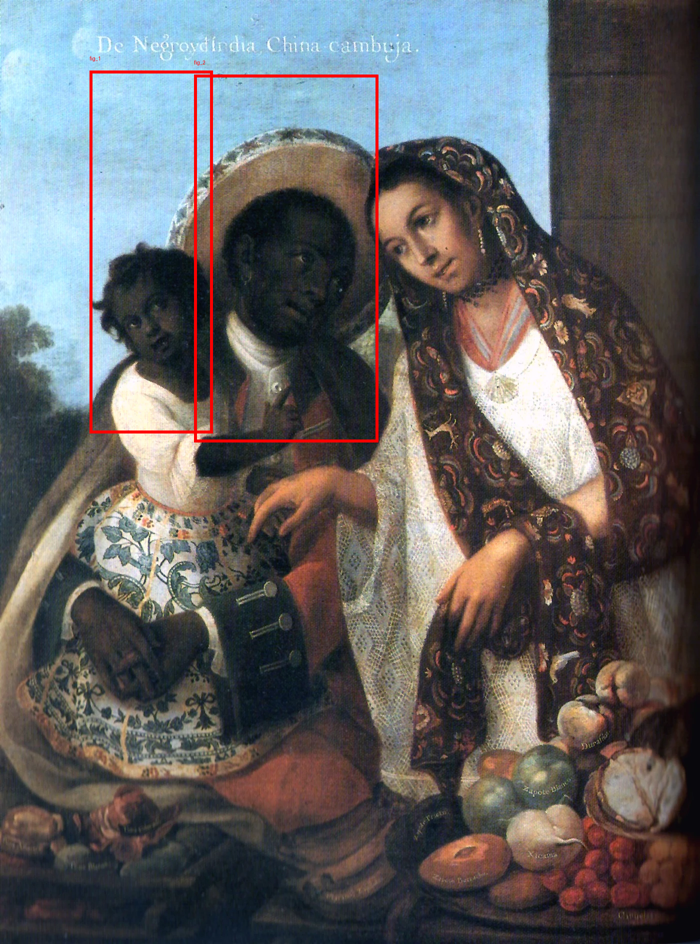


Procesando 11484 (esperado: 1/15) ...
  Qwen devolvio 1 caja(s), esperabamos 1


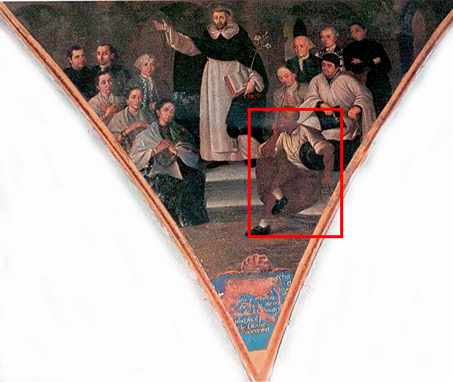


Procesando 90001 (esperado: 13/13) ...
  Qwen devolvio 7 caja(s), esperabamos 13


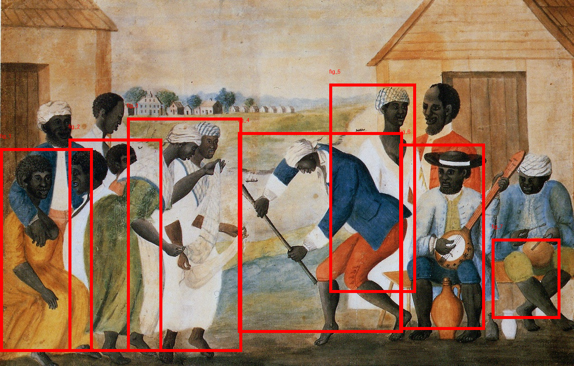


Procesando 90002 (esperado: 3/3) ...
  Qwen devolvio 3 caja(s), esperabamos 3


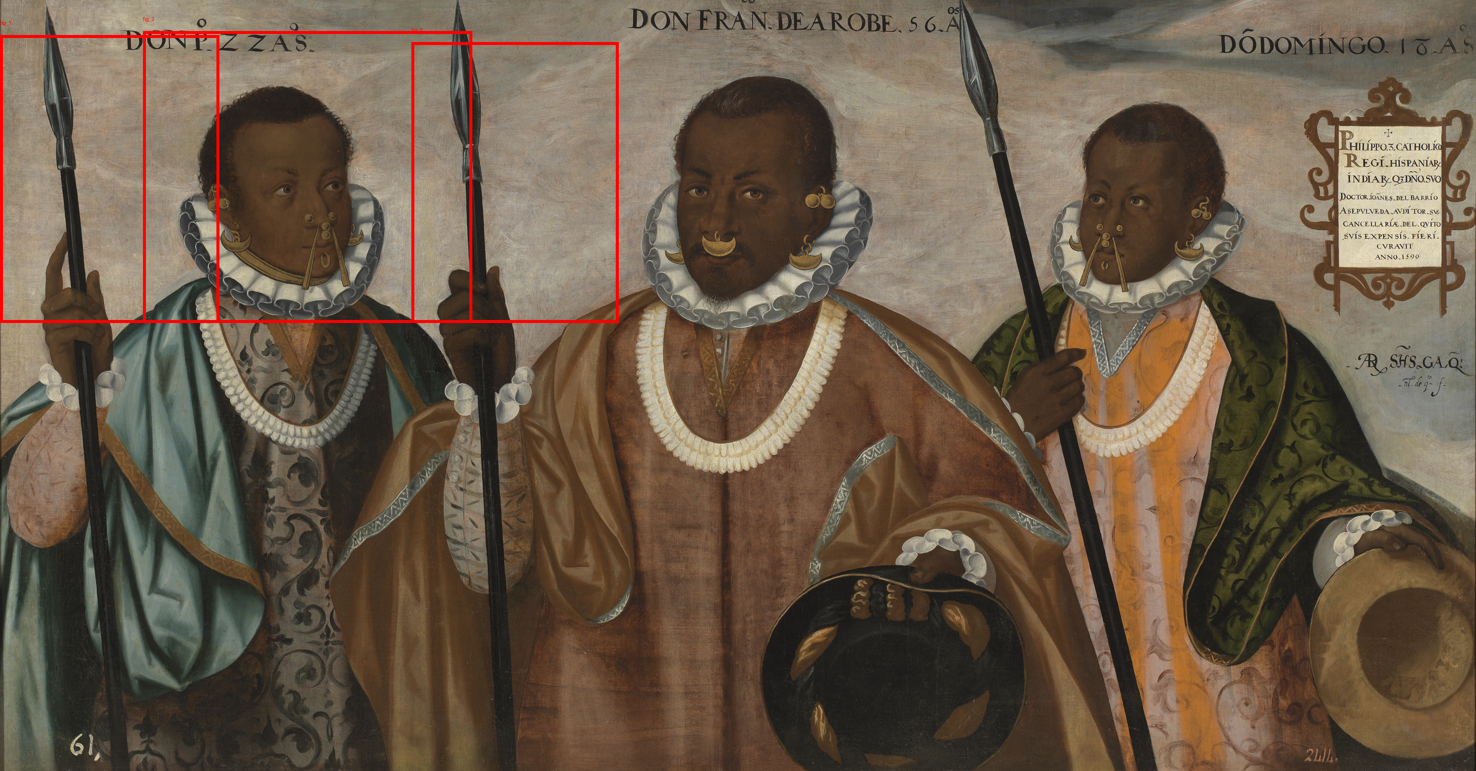

In [27]:
qwen_results = []

for r in records:
    print(f"Procesando {r['image_id']} (esperado: {r['number_of_afrodescendants']}/{r['total_figures']}) ...")
    boxes = run_qwen_grounding(r["image_path"], r["total_figures"], r["number_of_afrodescendants"])
    print(f"  Qwen devolvio {len(boxes)} caja(s), esperabamos {r['number_of_afrodescendants']}")

    img = Image.open(r["image_path"]).convert("RGB")
    draw = ImageDraw.Draw(img)
    for i, box in enumerate(boxes):
        draw.rectangle(box, outline="red", width=6)
        draw.text((box[0], box[1] - 30), f"fig_{i+1}", fill="red")
        qwen_results.append({"image_id": r["image_id"], "box_index": i, "qwen_bbox": box})

    display(img.resize((img.width // 2, img.height // 2)))
    print()


**Revisar:** ¿el número de cajas devueltas coincide con `number_of_afrodescendants`, o el modelo está inventando cajas hasta completar el número que le dimos (en vez de detectar honestamente)? Vale la pena mirar 1-2 casos donde el conteo no coincida para diagnosticar cuál de los dos está pasando.